# Complete KNN Pipeline (From Scratch)

## Step 1: Loads CIFAR-10 Dataset

In [1]:
#imports modules
import numpy as np
import matplotlib.pyplot as plt
import scipy
np.random.seed(42)

In [2]:
#function to extract images from CIFAR-10 readme
def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

In [3]:
#reads and 'unfolds' data from CIFAR-10 using helper function above
# base_dir = r"/home/disk_2/Coding/CS231N/datasets/CIFAR10/cifar-10-python/cifar-10-batches-py/"
# b1 = unpickle(base_dir + r"data_batch_1") 
# b2 = unpickle(base_dir + r"data_batch_2")
# b3 = unpickle(base_dir + r"data_batch_3")
# b4 = unpickle(base_dir + r"data_batch_4")
# b5 = unpickle(base_dir + r"data_batch_5")

In [4]:
#function to extract images from CIFAR-10 readme - extracts only data and labels in x,y format
my_keys = [b'data',b'labels']
def unpickle_mod(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
        dict = {key:dict[key] for key in my_keys}
    return dict

In [5]:
#reads and 'unfolds' data from CIFAR-10 using helper function above - only x and y components
base_dir = r"/home/disk_2/Coding/CS231N/datasets/CIFAR10/cifar-10-python/cifar-10-batches-py/"
b1_mod = unpickle_mod(base_dir + r"data_batch_1") 
b2_mod = unpickle_mod(base_dir + r"data_batch_2")
b3_mod = unpickle_mod(base_dir + r"data_batch_3")
b4_mod = unpickle_mod(base_dir + r"data_batch_4")
b5_mod = unpickle_mod(base_dir + r"data_batch_5")
test_mod = unpickle_mod(base_dir + r"test_batch")

In [6]:
#reads english labels corresponding to numeric labels
eng_labels = unpickle(base_dir + r"batches.meta") 

#creates mapping for labels from numbers to english labels
label_map = dict(zip(range(10),eng_labels[b'label_names']))
label_map

{0: b'airplane',
 1: b'automobile',
 2: b'bird',
 3: b'cat',
 4: b'deer',
 5: b'dog',
 6: b'frog',
 7: b'horse',
 8: b'ship',
 9: b'truck'}

## Step 2: Visualizing the dataset

b'truck'


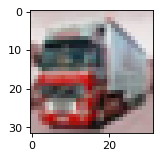

In [7]:
#set index to pull out an image
idx = 8000

#pull out image and label 
ex = b2_mod[b'data'][idx]
ex_label = b2_mod[b'labels'][idx]

#resize image from CIFAR10 data into 3-D numpy array -- note here that numpy follows (depth, rows, columns) nomenclature
ex_new = np.reshape(ex, (3,32,32))

#prints label and the image
print(label_map[ex_label])
plt.figure(figsize = (2,2), dpi = 80)
plt.imshow(ex_new.transpose(1, 2, 0))
plt.show()

## Step 3: Writing a KNN Classifier

### Step 3.1: Data Normalization

In [8]:
#running pre-processing in batches
def normalize_data(batch):
    batch_train = batch[b'data']
    batch_train_mean = batch_train.mean(axis=1).reshape(batch_train.shape[0],1)
    # print(batch_train_mean.shape)
    batch_train_var = batch_train.var(axis=1).reshape(batch_train.shape[0],1)
    # print(batch_train_var.shape)
    batch_train_x = (batch_train - batch_train_mean)/np.sqrt(batch_train_var)
    print(batch_train_x.shape)
    print(np.round(batch_train_x.mean(axis = 1).max(),2))
    print(np.round(batch_train_x.var(axis = 1).min(),2))
    print(np.round(batch_train_x.var(axis = 1).max(),2))
    return batch_train_x, batch_train_mean, batch_train_var

In [9]:
b1_mod_train_x = normalize_data(b1_mod)[0]
b2_mod_train_x = normalize_data(b2_mod)[0]
b3_mod_train_x = normalize_data(b3_mod)[0]
b4_mod_train_x = normalize_data(b4_mod)[0]
b5_mod_train_x = normalize_data(b5_mod)[0]
test_mod_x = normalize_data(test_mod)[0]

(10000, 3072)
0.0
1.0
1.0
(10000, 3072)
0.0
1.0
1.0
(10000, 3072)
0.0
1.0
1.0
(10000, 3072)
0.0
1.0
1.0
(10000, 3072)
0.0
1.0
1.0
(10000, 3072)
0.0
1.0
1.0


In [10]:
b1_mod_train_y = np.array(b1_mod[b'labels'], dtype = np.int8)
b2_mod_train_y = np.array(b2_mod[b'labels'], dtype = np.int8)
b3_mod_train_y = np.array(b3_mod[b'labels'], dtype = np.int8)
b4_mod_train_y = np.array(b4_mod[b'labels'], dtype = np.int8)
b5_mod_train_y = np.array(b5_mod[b'labels'], dtype = np.int8)
test_mod_y = np.array(test_mod[b'labels'], dtype = np.int8)

In [11]:
#memory mgt
del b1_mod,b2_mod,b3_mod,b4_mod,b5_mod

In [12]:
#qc
print(b1_mod_train_y.shape)
print(b1_mod_train_y.dtype)
print(test_mod_y.shape)
print(test_mod_y.dtype)

(10000,)
int8
(10000,)
int8


### Step 3.2 Writing KNN classifier - first attempt

In [13]:
# class KNearestNeighbour(object):
    
#     def __init__(self):
#         pass
    
#     #at train time, the KNN classifier just remembers all data
#     def train(self, x, y):
#         self.x_train = x
#         self.y_train = y

#     def test(self, x_test, distance = 'L1'):
#         self.x_test = x_test
            
#         #reshapes train and test - more memory efficient than np.tile() which copies data, newaxis just introduces a new axis with value = 1. 
#         #Numpy will later use this axis to broadcast
#         reshape_train = self.x_train[np.newaxis, :, :]
#         reshape_test = self.x_test[:, np.newaxis, :]
        
#         if distance == 'L1':
#             #compute L1 distance over all examples in the training set - use vectorized code instead of loops
#             dist_matrix_sum = np.abs(reshape_train - reshape_test).sum(axis = 2)
#             idx_least_dist = np.argmin(dist_matrix_sum, axis = 1)
#             y_pred = self.y_train[idx_least_dist]
            
#             return y_pred
            
#         if distance == 'L2':
#             #compute L2 distance over all examples in the training set - use vectorized code instead of loops
#             dist_matrix_sum = np.sqrt( ( (reshape_train - reshape_test) ** 2).sum(axis = 2))
#             idx_least_dist = np.argmin(dist_matrix_sum, axis = 1)
#             y_pred = self.y_train[idx_least_dist]
            
#             return y_pred

In [14]:
#builds training set
# train_x = np.concatenate((b1_mod_train_x, b2_mod_train_x, b3_mod_train_x, b4_mod_train_x, b5_mod_train_x))
# train_y = np.concatenate((b1_mod_train_y, b2_mod_train_y, b3_mod_train_y, b4_mod_train_y, b5_mod_train_y))
# print(train_x.shape)
# print(train_y.shape)

In [15]:
#builds test set 
# test_x = np.array(test_mod_x[5:7])
# test_y = np.array(test_mod_y[5:7])
# print(test_x.shape)
# print(test_y)

In [16]:
#moment of truth - trains and tests KNN classifier above
# knn = KNearestNeighbour()
# knn.train(train_x, train_y)
# test_pred_y = knn.test(test_x, distance = 'L1')

### Step 3.3 Defines an accuracy class

In [17]:
#accuracy function
class accuracy(object):
    
    def __init__(self):
        pass
        
    def calculate(self, y_pred, y_true):
        self.y_pred = y_pred
        self.y_true = y_true
        #counts same labels, divides it by total size of array
        self.acc = np.count_nonzero((np.abs(y_pred-y_true))==0)/np.size(self.y_true)
        return float(self.acc)
    

### Step 3.4 KNearest Neighbor with k>1 (voting mechanism) with batch implementation

In [18]:
class KNN(object):
    
    def __init__(self, k):
        self.k = k
    
    #at train time, the KNN classifier just remembers all data
    def train(self, x, y):
        self.x_train = x
        self.y_train = y

    def test(self, x_test, batch_size, distance = 'L1'):
        self.x_test = x_test
        self.batch_size = batch_size     

        #reshapes train 
        reshape_train = self.x_train[np.newaxis, :, :]
        y_pred = np.empty(x_test.shape[0])

        loop_end = int(np.ceil(self.x_test.shape[0]/batch_size))
        
        for i in range(loop_end):
            print('Batch '+ str(i)+' started. Total batches : ' + str(loop_end))
            
            #defines start and end of batch
            start = (i*batch_size)
            end = min( ((i+1)*batch_size), self.x_test.shape[0] )
            
            #reshapes test - more memory efficient than np.tile() which copies data, newaxis just introduces a new axis with value = 1. 
            #Numpy will later use this axis to broadcast
            reshape_test = self.x_test[start:end][:, np.newaxis, :]
                
            if distance == 'L2':
                #compute L2 distance over all examples in the training set - use vectorized code instead of loops
                dist_matrix_sum = np.sqrt( ( (reshape_train - reshape_test) ** 2).sum(axis = 2))

            else:
                #compute L1 distance over all examples in the training set - use vectorized code instead of loops
                dist_matrix_sum = np.abs(reshape_train - reshape_test).sum(axis = 2)
                
            #get the index of k elements having least difference with test image(s)
            idx_least_dist = np.argpartition(a = dist_matrix_sum, kth = self.k, axis = 1)[:,:self.k]
            #first, selects y label associated with k indices above, then gets the mode of the labels which becomes our y_pred
            y_pred[start:end] = scipy.stats.mode(self.y_train[idx_least_dist], axis = 1, keepdims = False)[0]
                
        return y_pred.astype(np.int8)

### Step 3.5 Builds train and test datasets

In [19]:
#builds train set - shuffling dataset in the process
train_x_int = np.concatenate((b1_mod_train_x, b2_mod_train_x, b3_mod_train_x, b4_mod_train_x, b5_mod_train_x))
train_y_int = np.concatenate((b1_mod_train_y, b2_mod_train_y, b3_mod_train_y, b4_mod_train_y, b5_mod_train_y))
np.random.seed(42)
indices = np.random.permutation(train_x_int.shape[0])
train_x = train_x_int[indices]
train_y = train_y_int[indices]
print(train_x.shape)
print(train_y.shape)

(50000, 3072)
(50000,)


In [20]:
#builds test set - shuffling dataset in the process
np.random.seed(42)
indices = np.random.permutation(test_mod_x.shape[0])
test_x = test_mod_x[indices]
test_y = test_mod_y[indices]
print(test_x.shape)
print(test_y.shape)

(10000, 3072)
(10000,)


#### Applies KNN Algo and Estimate Accuracy (To check if the code above works)

In [21]:
#moment of truth - trains and tests KNN classifier above
knn = KNN(k=20)
knn.train(x = train_x[:100], y = train_y[:100])
test_pred_y = knn.test(test_x[:10], distance = 'L1', batch_size = 2)

Batch 0 started. Total batches : 5
Batch 1 started. Total batches : 5
Batch 2 started. Total batches : 5
Batch 3 started. Total batches : 5
Batch 4 started. Total batches : 5


In [22]:
acc = accuracy()
acc.calculate(y_pred = test_pred_y, y_true = test_y[:10])

0.4

## Step 4 Cross Validation

In [23]:
class KNN_CV(object):

    def __init__(self, m, x_train, y_train, folds, batch_size):
        #m is 'k' in k nearest neighbours, changing variable name to avoid confusion while calling KNN class
        self.m = m
        #random shuffle of x and y dataset such that indices are aligned
        np.random.seed(42)
        indices = np.random.permutation(x_train.shape[0])
        self.x_train = x_train[indices]
        self.y_train = y_train[indices]
        self.folds = folds
        self.batch_size = batch_size

    def calculate(self):
        
        div_x = np.array_split(self.x_train, self.folds)
        div_y = np.array_split(self.y_train, self.folds)

        acc_lst = []

        for i in range(self.folds):
            print('Fold ' + str(i) + ' started. Total folds : ' + str(int(self.folds)))
            #defines hold out folds
            holdout_x = div_x[i]
            holdout_y = div_y[i]

            #defines training folds
            train_x_subset = np.concatenate([div_x[j] for j in range(self.folds) if j!= i])
            train_y_subset = np.concatenate([div_y[j] for j in range(self.folds) if j!= i])

            #train algo and then test on hold out
            #calls KNN class defined above
            knn = KNN(k=self.m)
            knn.train(x = train_x_subset, y = train_y_subset)
            #test using hardcoded batch size of 5
            test_pred_y = knn.test(holdout_x, distance = 'L1', batch_size = self.batch_size)
            
            #gets accuracy on holdout and append to the accuracy list
            acc = accuracy()
            acc_num = acc.calculate(y_pred = test_pred_y, y_true = holdout_y)
            acc_lst.append(acc_num)
            print('\n')

        return acc_lst

In [25]:
# cross_val = KNN_CV(m=5, x_train = train_x[:1000], y_train = train_y[:1000], folds = 5, batch_size = 100)
# cross_val.calculate()

### Step 4.1 Choosing the right 'k' in knn algo through CV

In [26]:
nrst_neigh_choice = [1,3,5,7,9,15,21,31,51,71,91,101]
my_dict = {}
for i in nrst_neigh_choice:
    cross_val = KNN_CV(m=i, x_train = train_x[:1000], y_train = train_y[:1000], folds = 5, batch_size = 100)
    acc_lst = cross_val.calculate()
    my_dict[i] = float(np.average(acc_lst))

Fold 0 started. Total folds : 5
Batch 0 started. Total batches : 2
Batch 1 started. Total batches : 2


Fold 1 started. Total folds : 5
Batch 0 started. Total batches : 2
Batch 1 started. Total batches : 2


Fold 2 started. Total folds : 5
Batch 0 started. Total batches : 2
Batch 1 started. Total batches : 2


Fold 3 started. Total folds : 5
Batch 0 started. Total batches : 2
Batch 1 started. Total batches : 2


Fold 4 started. Total folds : 5
Batch 0 started. Total batches : 2
Batch 1 started. Total batches : 2


Fold 0 started. Total folds : 5
Batch 0 started. Total batches : 2
Batch 1 started. Total batches : 2


Fold 1 started. Total folds : 5
Batch 0 started. Total batches : 2
Batch 1 started. Total batches : 2


Fold 2 started. Total folds : 5
Batch 0 started. Total batches : 2
Batch 1 started. Total batches : 2


Fold 3 started. Total folds : 5
Batch 0 started. Total batches : 2
Batch 1 started. Total batches : 2


Fold 4 started. Total folds : 5
Batch 0 started. Total batches :

In [27]:
import copy
my_dict_copy = copy.deepcopy(my_dict)

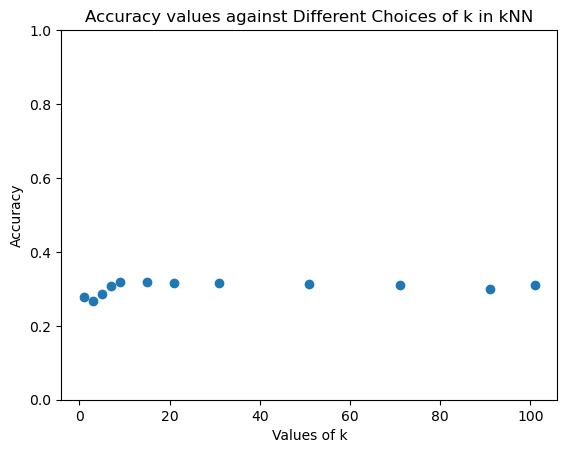

In [28]:
#creates a visual for accuracy levels across different choice of k
x = list(my_dict_copy.keys())
y = my_dict_copy.values()

plt.scatter(x,y)
plt.ylim(0,1)
plt.xlabel('Values of k')
plt.ylabel('Accuracy')
plt.title('Accuracy values against Different Choices of k in kNN')
plt.show()

In [29]:
#sorting choice of k in descending order of accuracy
sorted(my_dict_copy, key = my_dict_copy.get, reverse = True)

[9, 15, 31, 21, 51, 101, 71, 7, 91, 5, 1, 3]

## Step 5 Using the k = 9 and generating accuracy on actual test dataset

In [30]:
#builds test set 
test_x_sub = test_x[:100]
test_y_sub = test_y[:100]

print(test_x_sub.shape)
print(test_y_sub.shape)

(100, 3072)
(100,)


In [31]:
#moment of truth - trains and tests KNN classifier above
knn = KNN(k=9)
knn.train(x = train_x[:1000], y = train_y[:1000])
test_pred_y = knn.test(test_x_sub, distance = 'L1', batch_size = 10)

Batch 0 started. Total batches : 10
Batch 1 started. Total batches : 10
Batch 2 started. Total batches : 10
Batch 3 started. Total batches : 10
Batch 4 started. Total batches : 10
Batch 5 started. Total batches : 10
Batch 6 started. Total batches : 10
Batch 7 started. Total batches : 10
Batch 8 started. Total batches : 10
Batch 9 started. Total batches : 10


In [32]:
acc = accuracy()
acc.calculate(y_pred = test_pred_y, y_true = test_y_sub)

0.26